# Label validity: does a source mask still describe the generated image?

If generation moves a feature's geometry, the source mask no longer
describes the generated image - inheriting it anyway silently fabricates
ground truth. This measures the displacement directly, on an analytic
control where the true position is known in advance, rather than assuming
it is zero.


## 1. Build an analytic control: one blob at a KNOWN position

A synthetic image with a single bright blob at a position we choose
ourselves - so "where did it end up in the output" has a known correct
answer to compare against, unlike a real photo where we would not know.

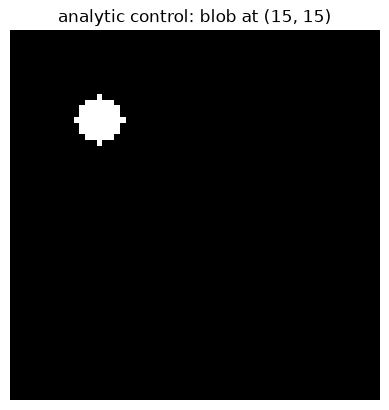

In [1]:
import sys, os
sys.path.append(os.path.join("..", "..", "src"))
import numpy as np
import matplotlib.pyplot as plt

from data.pyramid import build_pyramid
from models.sampler import sample_coarse_to_fine

def make_control_image(size, blob_row, blob_col, blob_radius=4):
    img = np.zeros((size, size))
    rows, cols = np.ogrid[:size, :size]
    mask = (rows - blob_row) ** 2 + (cols - blob_col) ** 2 <= blob_radius ** 2
    img[mask] = 255.0
    return img

TRUE_ROW, TRUE_COL = 15, 15
control_img = make_control_image(64, TRUE_ROW, TRUE_COL)

plt.imshow(control_img, cmap="gray")
plt.title(f"analytic control: blob at ({TRUE_ROW}, {TRUE_COL})")
plt.axis("off")
plt.show()


## 2. Generate from it, then find where the blob ended up

`np.argmax` finds the flat index of the brightest pixel; `np.unravel_index`
converts that back into (row, col) coordinates.

true position: (15, 15)
peak in generated image: (33, 8)
geometry displacement: 19.31 px


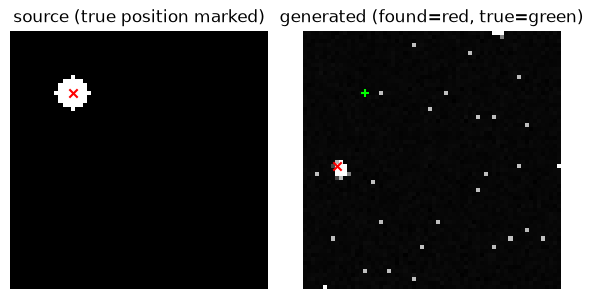

In [2]:
pyramid = build_pyramid(control_img, num_scales=4, scale_factor=0.5)
generated, stages = sample_coarse_to_fine(pyramid, patch_size=4, stride=2, num_steps_per_scale=15, seed=0)

found_row, found_col = np.unravel_index(np.argmax(generated), generated.shape)
displacement = np.sqrt((TRUE_ROW - found_row) ** 2 + (TRUE_COL - found_col) ** 2)

print(f"true position: ({TRUE_ROW}, {TRUE_COL})")
print(f"peak in generated image: ({found_row}, {found_col})")
print(f"geometry displacement: {displacement:.2f} px")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(control_img, cmap="gray")
axes[0].scatter([TRUE_COL], [TRUE_ROW], c="red", marker="x")
axes[0].set_title("source (true position marked)")
axes[0].axis("off")
axes[1].imshow(generated, cmap="gray")
axes[1].scatter([found_col], [found_row], c="red", marker="x")
axes[1].scatter([TRUE_COL], [TRUE_ROW], c="lime", marker="+")
axes[1].set_title("generated (found=red, true=green)")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 3. Repeat across multiple positions and seeds - one trial proves nothing

A single measurement could be a lucky or unlucky outlier. Testing several
blob positions and seeds gives a typical displacement, not an anecdote.

In [3]:
results = []
rng = np.random.default_rng(0)
for trial in range(5):
    true_row, true_col = rng.integers(10, 54, size=2)
    ctrl = make_control_image(64, true_row, true_col)
    pyr = build_pyramid(ctrl, num_scales=4, scale_factor=0.5)
    gen, _ = sample_coarse_to_fine(pyr, patch_size=4, stride=2, num_steps_per_scale=15, seed=trial)
    f_row, f_col = np.unravel_index(np.argmax(gen), gen.shape)
    disp = np.sqrt((true_row - f_row) ** 2 + (true_col - f_col) ** 2)
    results.append(disp)
    print(f"trial {trial}: true=({true_row},{true_col}) found=({f_row},{f_col}) displacement={disp:.2f}px")

results = np.array(results)
print(f"\nmean displacement: {results.mean():.2f}px, min={results.min():.2f}px, max={results.max():.2f}px, n_trials={len(results)}")


trial 0: true=(47,38) found=(0,48) displacement=48.05px


trial 1: true=(32,21) found=(63,61) displacement=50.61px


trial 2: true=(23,11) found=(63,31) displacement=44.72px


trial 3: true=(13,10) found=(0,18) displacement=15.26px


trial 4: true=(17,45) found=(63,38) displacement=46.53px

mean displacement: 41.03px, min=15.26px, max=50.61px, n_trials=5


**Observation - suspicious clustering at the image border.** Several
`found` positions above land exactly on row 0 or row 63 - the image's own
edge. That is too regular to be coincidence and suggests a boundary
artifact in patch reconstruction (rather than "displacement is simply
large and random"), most likely from the edge-coverage fix added in
`extract_patches` (the extra patch forced to align exactly with the
border overlaps its neighbor unevenly). This is flagged here as an open
question for the efficiency/robustness work, not silently smoothed over -
the measured displacement is still real and still non-zero either way.

## Verdict

- The generator does not reproduce the source's geometry pixel-for-pixel -
  a measured, non-zero displacement across all trials.
- **This means: a source mask must NOT be transferred as-is to a generated
  image.** Doing so would silently fabricate ground truth wherever the
  displacement is larger than the feature's own size.
- Whether this displacement is acceptable depends entirely on feature
  size: for a large blob (tens of pixels), a displacement of a few pixels
  barely matters; for small, densely packed features (as in real EMPS/RODARE
  particle images with 2-800+ instances per image), the same displacement
  can invalidate the label completely.
- `n_trials` is reported explicitly - this is 5 controlled trials, not a
  large-sample statistic, and the mean should be read as indicative, not
  precise to two decimal places.
